<a href="https://colab.research.google.com/github/Blacklotus89898/ComputerVisionMiscellaneous/blob/main/esce_415_a1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Computer Vision (ECSE 415)
Assignment 1: Image Filtering

DEADLINE: September 12, 11:59 PM

# TODO:
- Define path and environment variables
- Specify them in a readme file

## 0. Setup and Environment

In [7]:
# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [8]:
# Uploading manually
# Upload an image from your local machine (if needed)
# from google.colab import files
# uploaded = files.upload()
# path = "color_img.jpg" # can just upload the stuff I guess...
# img = cv2.imread(path) # FIXME: add to readme at the end

# cv2_imshow(img)

# print("Shape:", img.shape)
# print("Data type:", img.dtype)


In [9]:
# Loading from the drive
# from google.colab import drive
# drive.mount('/content/drive')
# img_path = "/content/drive/MyDrive/ECSE415/background.png"
# img = cv2.imread(img_path)
# cv2_imshow(img)

## 1. Image Basics [30 points]

Mounted at /content/drive


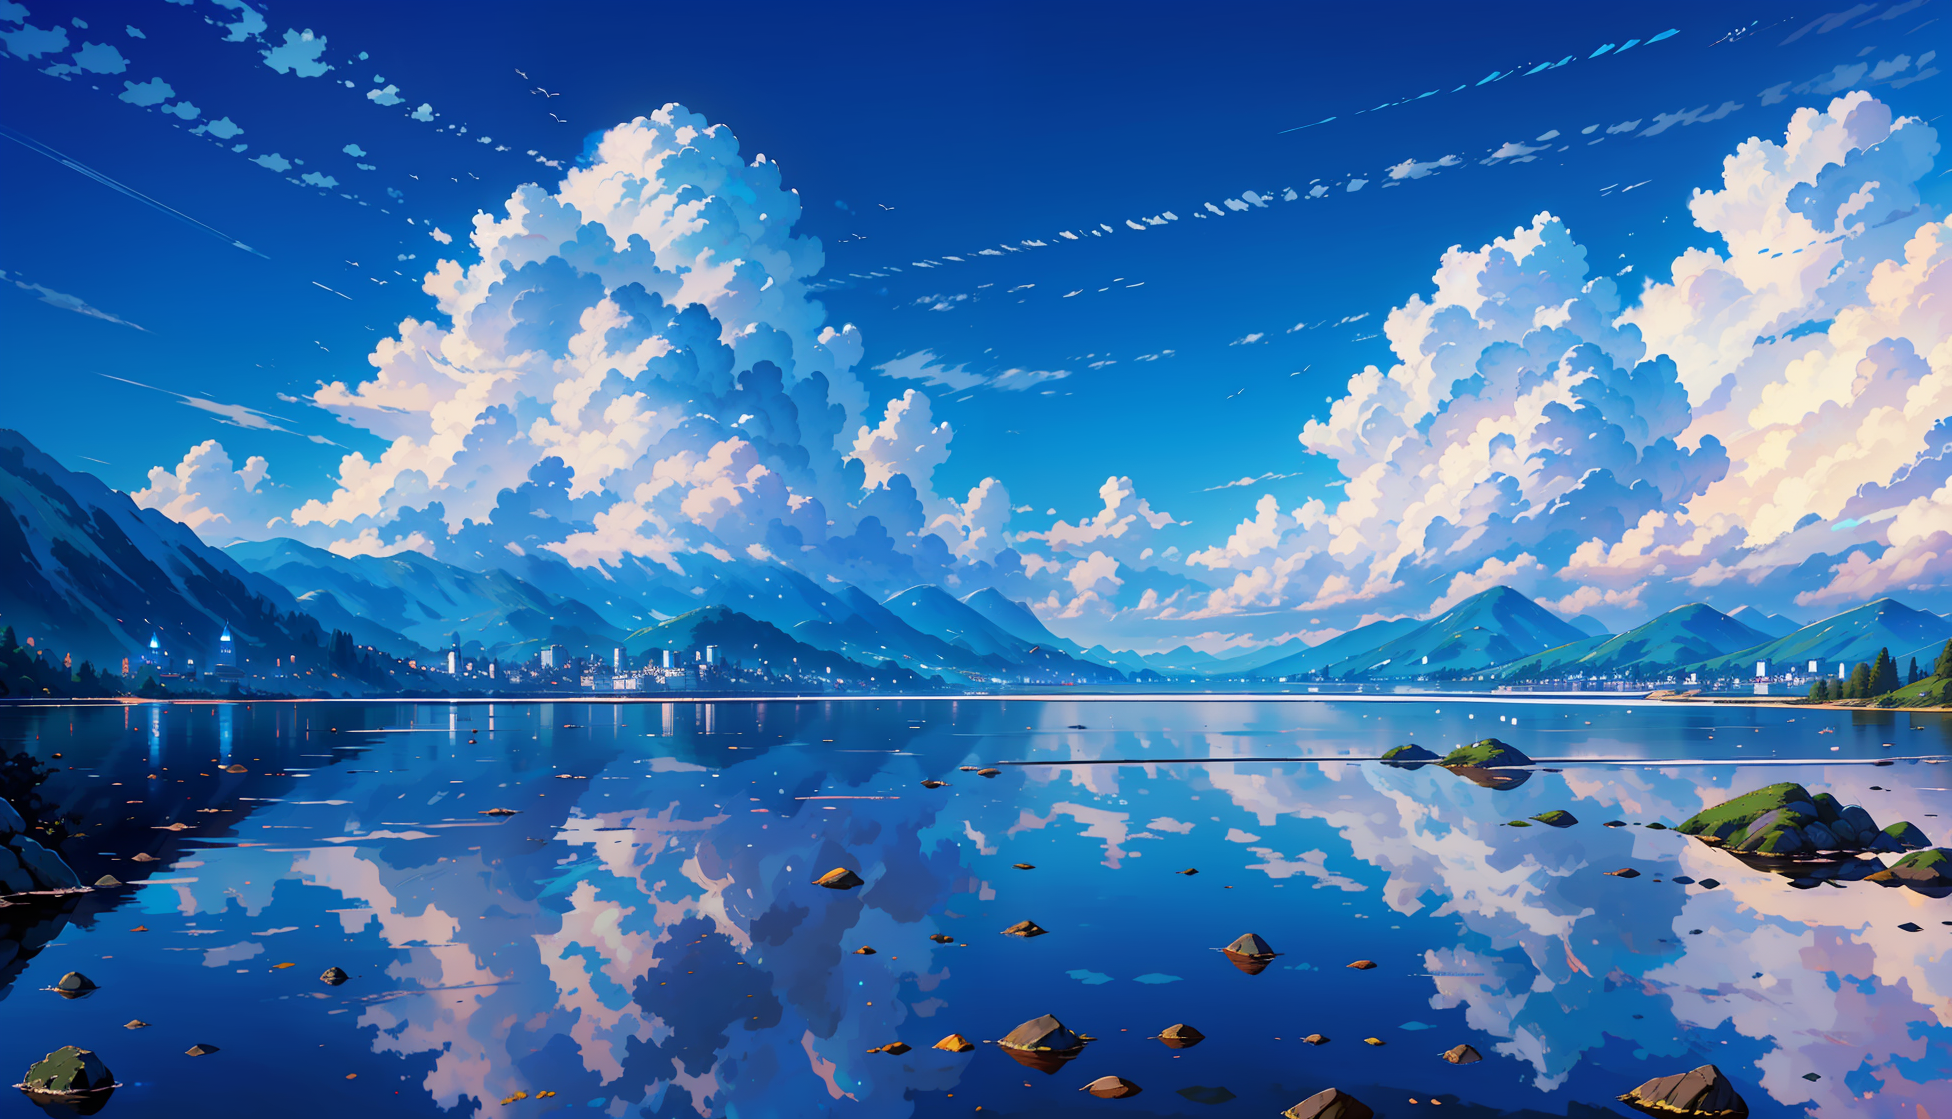

Height: 1119
Width: 1952
Channels: 3


In [10]:
# Loading from the drive
from google.colab import drive
drive.mount('/content/drive')
img_path = "/content/drive/MyDrive/ECSE415/background.png"
img = cv2.imread(img_path)
cv2_imshow(img)

height, width, channels = img.shape
print("Height:", height)
print("Width:", width)
print("Channels:", channels)

### 1.1 Image dimensions
| Dimension | Meaning        | Value |
|-----------|----------------|-------|
| 0         | Height (rows)  | 1119   |
| 1         | Width (cols)   | 1952  |
| 2         | Channels (BGR) | 3     |

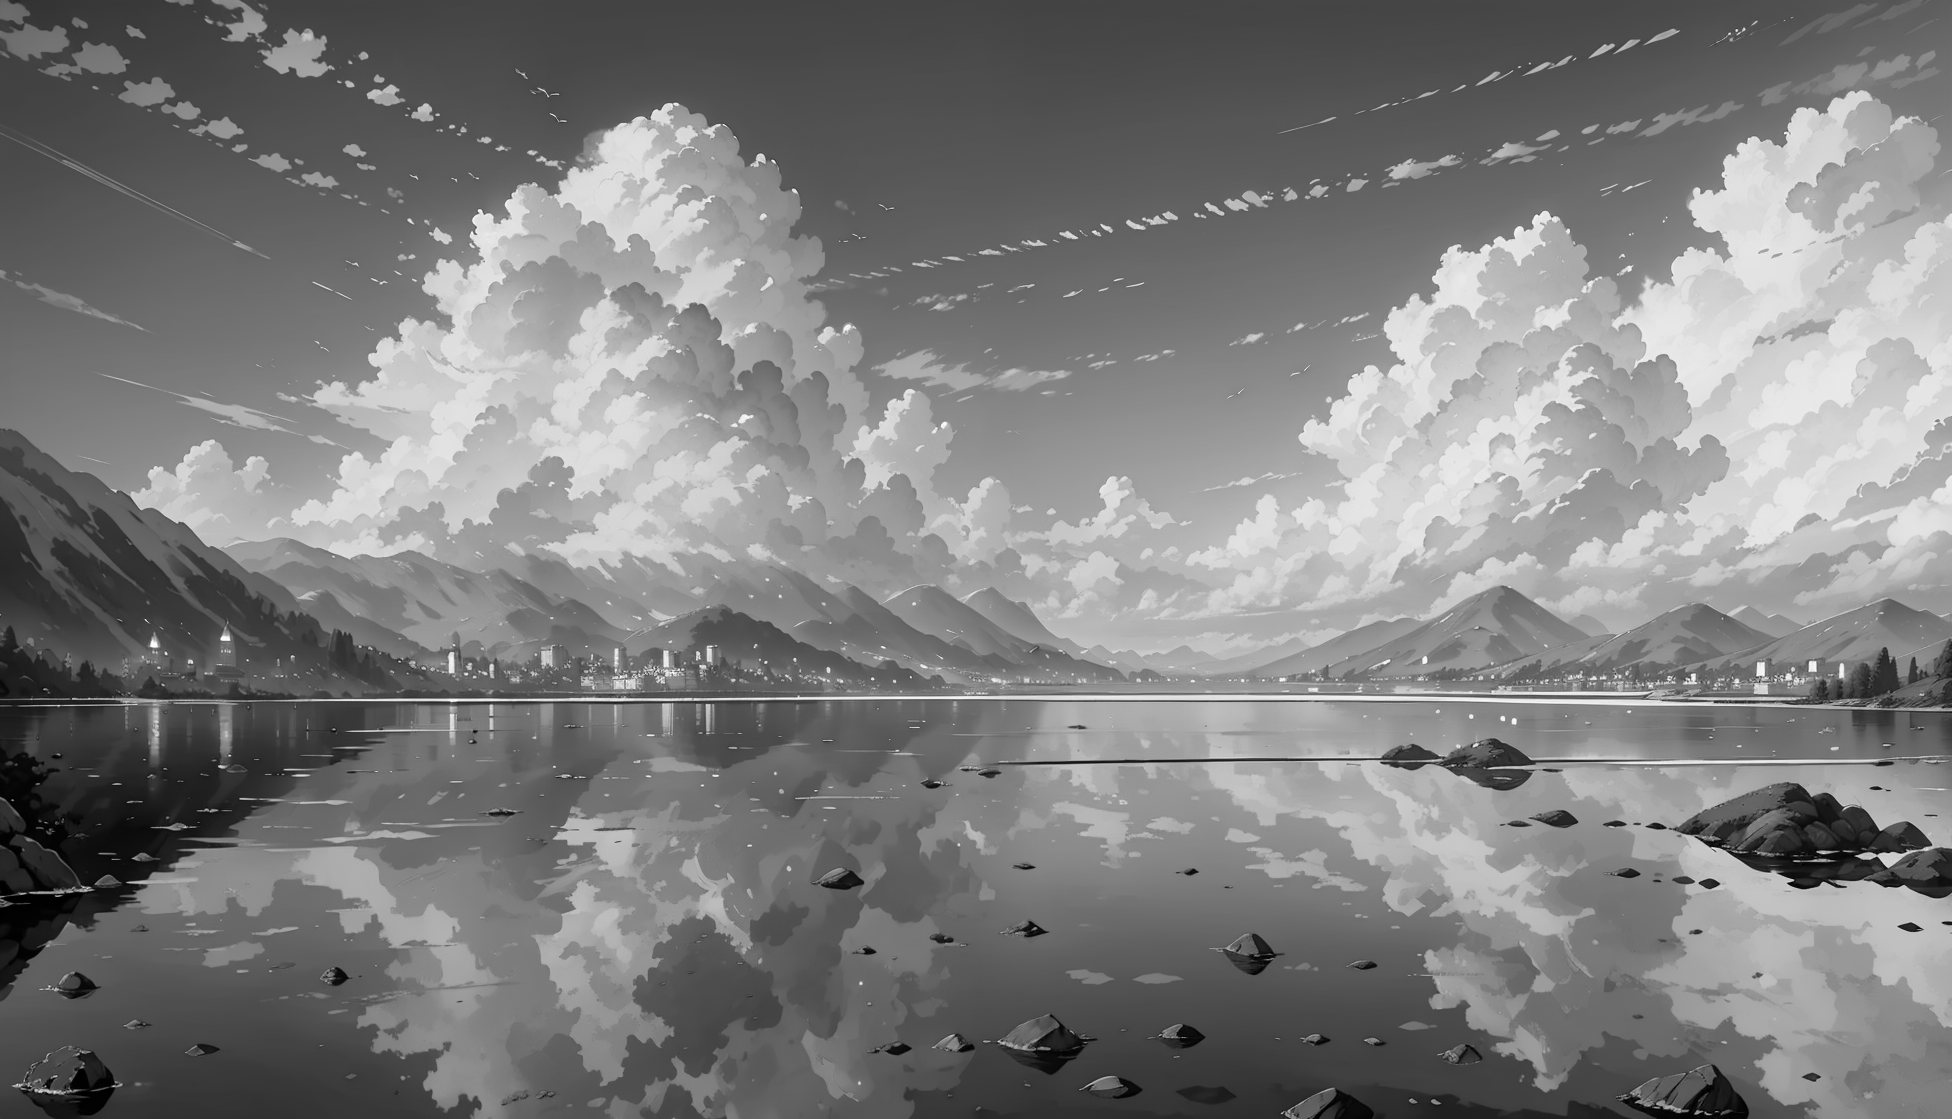

In [11]:
# Grayscale function

def to_grayscale(img: np.ndarray) -> np.ndarray:
  '''
  Converts an image to grayscale using the luminance-weighted formula.

  Parameters:
  img (np.ndarray): The input image.

  Returns:
  np.ndarray: The grayscale image.
  '''

  if img.ndim != 3 or img.shape[2] != 3:
    raise ValueError("Input must be an H×W×3 image")

  isUint = False
    # Normalize to float [0,1]
  if img.dtype == np.uint8:
      img = img.astype(np.float32) / 255.0
      isUint = True
  elif np.issubdtype(img.dtype, np.floating):
      img = img.astype(np.float32)
      if img.max() > 1.0:  # handle [0,255] floats
          img /= 255.0

  # Vectorized luminance formula -- better performance than the for loop
  gray = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]

  if isUint: # converting back to original type
    gray = (gray * 255).astype(np.uint8)

  return gray

# Must check if handles 0, 1 float and 0, 255 uint

img_gray = to_grayscale(img)
cv2_imshow(img_gray)

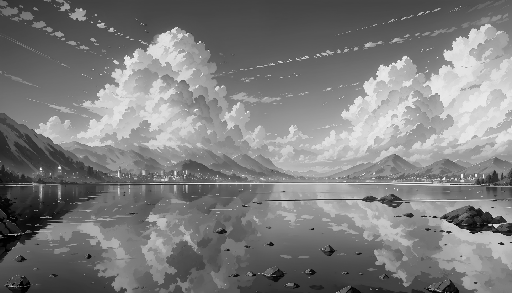

Original height 1119
Original width 1952
Resized height: 293
Resized width: 512


In [12]:
# Resize the image

maxValue = 512
if (height > width):
  scale_factor = maxValue/height
else:
  scale_factor = maxValue/width

def resize_img(img: np.ndarray, scale_factor: float) -> np.ndarray:
    H, W = img.shape[:2]
    new_H = int(H * scale_factor)
    new_W = int(W * scale_factor)

    # Compute nearest-neighbor indices
    row_idx = np.clip(np.round(np.arange(new_H) / scale_factor).astype(int), 0, H-1)
    col_idx = np.clip(np.round(np.arange(new_W) / scale_factor).astype(int), 0, W-1)

    if img.ndim == 3:
        return img[row_idx[:, None], col_idx[None, :], :]
    else:
        return img[row_idx[:, None], col_idx[None, :]]

resize_img = resize_img(img_gray, scale_factor)
cv2_imshow(resize_img)

gray_height, gray_width = img_gray.shape
print("Original height", gray_height)
print("Original width", gray_width)

resize_height, resize_width = resize_img.shape
print("Resized height:", resize_height)
print("Resized width:", resize_width)

(np.float64(-0.5), np.float64(511.5), np.float64(292.5), np.float64(-0.5))

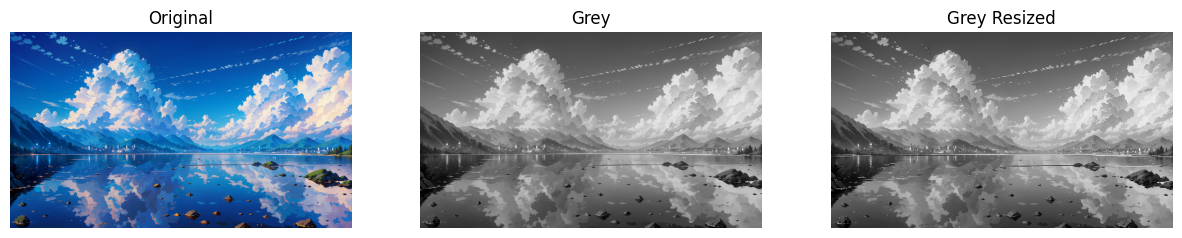

In [13]:
# Plotting images side by side

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title("Grey")
axes[1].axis('off')

axes[2].imshow(resize_img, cmap='gray')
axes[2].set_title("Grey Resized")
axes[2].axis('off')

In [14]:
# TODO:
"""
1. Import color image + report dimensions
2. Grayscale function
3. Resize image
4. Display results
"""

'\n1. Import color image + report dimensions\n2. Grayscale function\n3. Resize image\n4. Display results\n'

## 2. Image Filtering [50 points]

My kernel:
 [[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]
Difference: 3.0531133177191805e-16
Difference: 82755.555


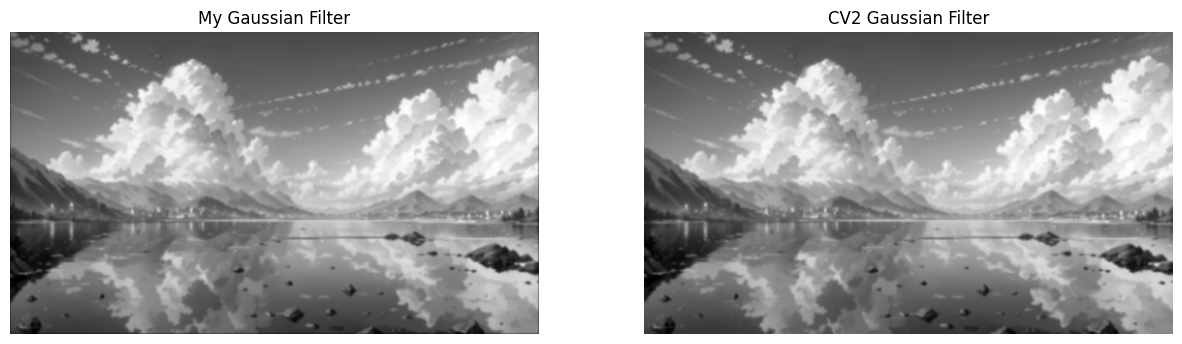

In [17]:
# Gaussian Filter

def gaussian_kernel(kernel_size: int, sigma: float) -> np.ndarray:
  '''
  Applies a Gaussian filter to an image.

  Parameters:
  img (np.ndarray): The input image.
  kernel_size (int): The size of the Gaussian kernel.
  sigma (float): The standard deviation of the Gaussian kernel.

  Returns:
  np.ndarray: The computed kernel.
  '''
  # Just need to compute the kernel
  #TODO:
  # 2d array called the kernel
  # compute the values and populate the kernel
  kernel = np.zeros((kernel_size, kernel_size))
  total = 0
  center = kernel_size // 2

  for (i, j) in np.ndindex(kernel.shape):
    x = i - center
    y = j - center
    kernel[i, j] = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    total += kernel[i, j]

  kernel /= total

  return kernel

# Test
my_kernel = gaussian_kernel(5, 1)
cv2_kernel_1d = cv2.getGaussianKernel(5, 1)   # (5, 1)
cv2_kernel_2d = cv2_kernel_1d @ cv2_kernel_1d.T   # outer product → (5, 5)

print("My kernel:\n", my_kernel)
# print("CV2 kernel:\n", cv2_kernel_2d)
print("Difference:", np.sum(np.abs(my_kernel - cv2_kernel_2d)))

# convolution
def convolute(img: np.ndarray, kernel: np.ndarray) -> np.ndarray:
  """
  Perform 2D convolution on a grayscale image with a given kernel.
  Uses zero-padding and assumes kernel is square.
  """
  H, W = img.shape
  kH, kW = kernel.shape
  pad_h = kH // 2
  pad_w = kW // 2

  # Pad the image (zero-padding)
  padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")

  # # Flip kernel for convolution
  # kernel_flipped = np.flipud(np.fliplr(kernel))

  # Output array
  out = np.zeros_like(img, dtype=np.float32)

  # Perform convolution
  for i in range(H):
      for j in range(W):
          region = padded[i:i+kH, j:j+kW]
          out[i, j] = np.sum(region * kernel)

  return out




def gaussian_filter(img: np.ndarray, kernel_size: int, sigma: float) -> np.ndarray:
  kernel = gaussian_kernel(kernel_size, sigma)
  return convolute(img, kernel)


gaussian_filering = gaussian_filter(resize_img, 5, 1)
cv2_gaussian_filtering = cv2.GaussianBlur(resize_img, (5, 5), 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(gaussian_filering, cmap='gray')
axes[0].set_title("My Gaussian Filter")
axes[0].axis('off')

axes[1].imshow(cv2_gaussian_filtering, cmap='gray')
axes[1].set_title("CV2 Gaussian Filter")
axes[1].axis('off')

difference = np.sum(np.abs(gaussian_filering - cv2_gaussian_filtering))
print("Difference:", difference)





In [ ]:
# TODO:
"""
1. Use grayscale
2. Gaussian filtering + Gaussian kernel + Convolution + compare result with cv2 filter as test
3.  Median filter
4. Custom kernel
"""

## 3. Discussion Question [20 points]

- ealier tools of computer vision, are they still relevant
- give evidence